### How Deep Neural Networks Work

At its core, a Deep Neural Network (DNN) is a hierarchical feature extractor. It takes raw data like pixels in an image or words in a sentence and transforms it step-by-step through stacked layers until it reaches a final prediction (like identifying a cat or predicting the next word).

**Forward pass** : Each layer in a network performs two simple operations:
- Linear Combination: Multiplies the incoming data ($x$) by a matrix of learnable weights ($W$) and adds a bias ($b$).
- Non-Linear Activation: Passes that result through a non-linear function (like ReLU, GELU, or Sigmoid).

**Backward pass**: 
To improve, the network calculates its error (loss) at the output and sends a correction signal backward through every layer, process called [backpropagation](wikipedia/backpropagation). Backpropagation relies on the **calculus chain rule**.

The chain rule dictates that to calculate the gradient for an early layer, you must multiply the derivatives (represented as Jacobian matrices, $\frac{\partial h_{k+1}}{\partial h_k}$) of every single layer that comes after it:$$\frac{\partial \mathcal{L}}{\partial \theta_l} = \frac{\partial \mathcal{L}}{\partial h_L} \cdot \prod_{k=l}^{L-1} \frac{\partial h_{k+1}}{\partial h_k} \cdot \frac{\partial h_l}{\partial \theta_l}$$The big capital $\prod$ symbol stands for product (multiplication across all layers from $l$ to $L-1$).

In simpler words, to figure out how to adjust the weights in Layer 1, the network multiplies the gradients (slopes) of every layer that came after it:$$\text{Gradient at Early Layer} \propto \text{Gradient at Output} \times (J_L \times J_{L-1} \times \dots \times J_2 \times J_1)$$Where each $J$ is a matrix of derivatives (Jacobian) for that specific layer.




### The Bottleneck

In theory, depth equals power. A 5-layer network might only recognize basic lines and textures. A 50-layer network can compose those lines into shapes, objects, and complex semantic concepts. Adding more layers should logically increase the network's capacity to learn complex patterns.

However, When researchers attempted to scale networks from 10 layers to 50 or 100 layers, they ran into a wall: deeper networks performed worse than shallow ones, even on the training data itself ! 

This was not overfitting (where a model memorizes training data but fails on test data). It was a fundamental optimization bottleneck caused by three major issues:

- The Vanishing Gradient Problem: Because backpropagation multiplies many fractional derivatives together ($0.9 \times 0.9 \times 0.9 \dots$), the error signal shrinks exponentially as it travels backward. By the time it reaches the first few layers, the gradient vanishes down to near zero. The early layers never learn. 

Imagine trying to pass a complex message down a line of 100 people via whispers. By the time it reaches the end, the original message is completely distorted or lost entirely.

- The Exploding Gradient Problem: Conversely, if the derivatives are slightly larger than $1.0$, multiplying dozens of them together causes the gradient signal to grow exponentially, overflowing into numeric error (NaN).

- The Identity Learning Barrier: Imagine a 20-layer network is already perfect for the job. If you stack 30 more layers on top, those extra layers should just "shrug" and pass the input straight through unchanged — that's all they need to do to keep things exactly as good as before. The problem is that each layer is built from weights and non-linear functions (like ReLU) designed to *transform* data, not copy it exactly. Asking gradient descent to tune those weights until the layer behaves like a perfect "do nothing" pass-through is a surprisingly awkward, unnatural target to hit — so instead of quietly matching the 20-layer performance, the extra layers introduce noise and actually make things worse.

### Residual connection (skip connection)

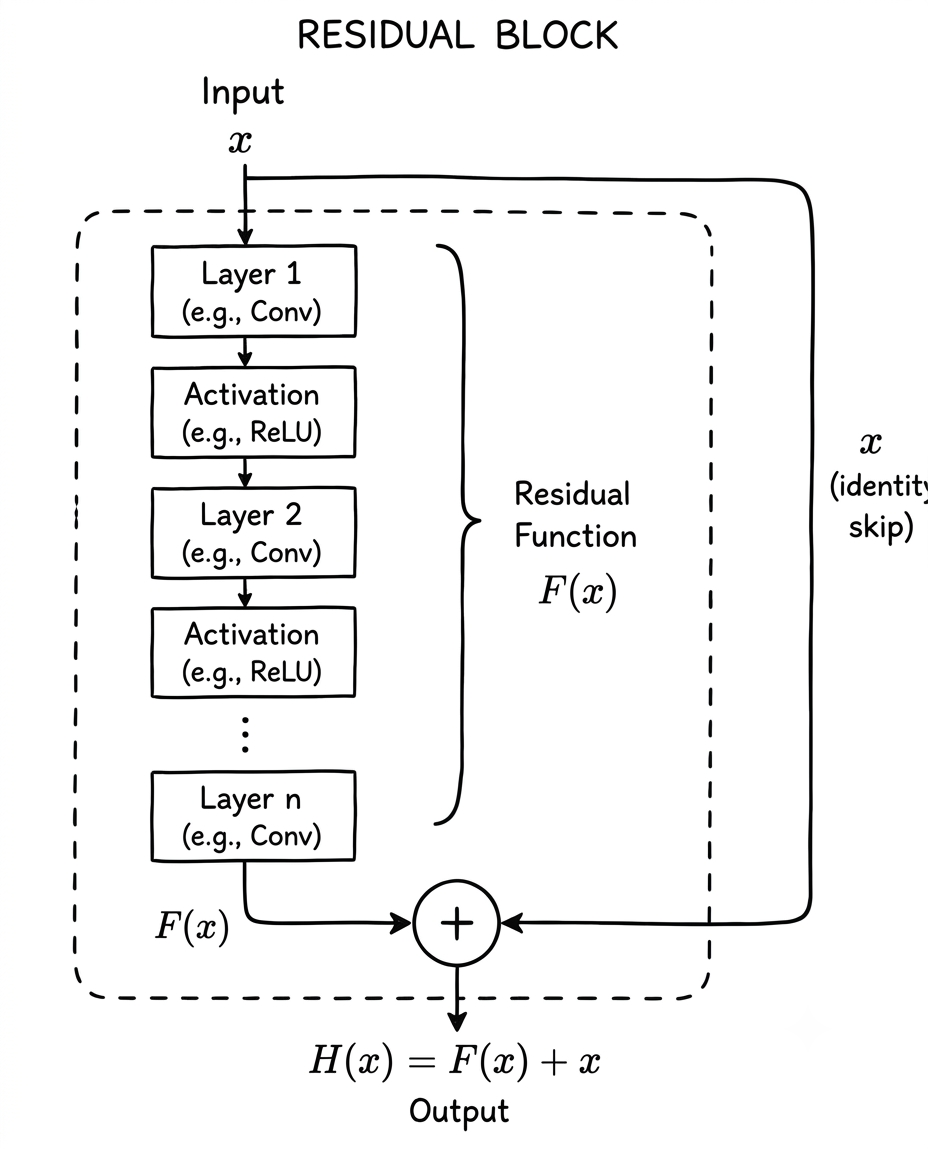

Residual connections reframe this problem. Instead of learning $H(x)$ directly, the weight layers are tasked with learning only the residual difference between the input and the target:
$$F(x) = H(x) - x$$
By adding the skip connection back to the output, the equation rearranges to:$$H(x) = F(x) + x$$

Where:
- $x$ is the original unaltered input passed down the shortcut.
- $F(x)$ is the residual (the refinement or change applied by the weight layers).
- $H(x)$ is the combined output.

Why Learning Residuals Is Easier ?

Imagine painting a picture. Standard networks try to paint the entire canvas from scratch at every layer. Residual networks give each layer an existing canvas ($x$) and only ask it to adjust the small details ($F(x)$).If a layer adds no value, the optimizer doesn't need to perform complex weight matching to pass the input through unedited ($W \cdot x = x$). It simply drives $F(x) \to 0$, reducing the block to $H(x) = 0 + x = x$. The data passes through completely untouched as a safe identity fallback.

### How Residual Connections Bypass the Gradient Problem

The true breakthrough occurs during backpropagation (how networks learn using derivatives)

In standard networks, gradients are computed using the calculus chain rule. To update an early layer, the error signal is repeatedly multiplied by the weight matrices of every layer that follows it:

$$\text{Gradient at Layer 1} \propto \text{Output Error} \times (J_L \times J_{L-1} \times \dots \times J_1)$$

When you multiply dozens of fractional numbers together, the total product shrinks exponentially toward zero. The gradient vanishes, leaving early layers completely untrained.

In calculus, the derivative of addition is always 1. Taking the derivative of a residual block output with respect to input $x$ yields:
$$\frac{\partial}{\partial x}[F(x) + x] = \frac{\partial F(x)}{\partial x} + 1$$

That constant $+1$ acts as an unblocked gradient superhighway.

During backpropagation, the error signal splits into two paths:
- One path goes through the weight layers ($\frac{\partial F(x)}{\partial x}$).
- The second path flows down the shortcut path ($+1$) completely unscaled.

Even if the gradient through the weight layers shrinks toward zero, the signal traveling through the $+1$ shortcut arrives at early layers intact. This converts backpropagation from a fragile multiplicative chain into a robust additive process.